# Task 2: Customer Segmentation Using Unsupervised Learning 
 
# Problem Statement:
Retail businesses often struggle to identify different customer groups and their unique spending behaviors, making it difficult to tailor marketing efforts effectively. 
# Objective:
To analyze mall customer data and use **K-Means Clustering** to segment customers based on their annual income and spending scores, providing actionable insights for business growth. 

# Dataset Description & Loading
The 'Mall Customers Dataset' is utilized for this analysis. The dataset is loaded into a pandas DataFrame, and an initial inspection of the dataset's shape and structure is performed. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# loading the Mall Customers Dataset
df=pd.read_csv('Mall_Customers.csv')

# Dataset Description 
print("Dataset Shape:",df.shape)
print("\nFirst 5 Rows:\n",df.head())
print("\nData Information:")
print(df.info())

Dataset Shape: (200, 5)

First 5 Rows:
    CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ 

# Data Cleaning & Preprocessing 
The dataset is checked for missing values to ensure data integrity. The features 'Annual Income' and 'Spending Score' are selected for the model. Furthermore, feature scaling is applied using StandardScaler so that all variables are treated with equal importance by the algorithm. 

In [11]:
# Checking for missing values 
print("Missing values in each column:\n",df.isnull().sum())

# Selecting features for clustering (Annual Income and Spending Score)
X=df.iloc[:,[3,4]].values

# Feature Scaling: Essential for distance-based algorithms like K-Means
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print("\nData preprocessing and scaling completed.")

Missing values in each column:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Data preprocessing and scaling completed.


# Exploratory Data Analysis (EDA)
The distribution of income and spending habits is visualized through histograms and density plots. Underlying patterns and potential outliers are identified during this stage. 

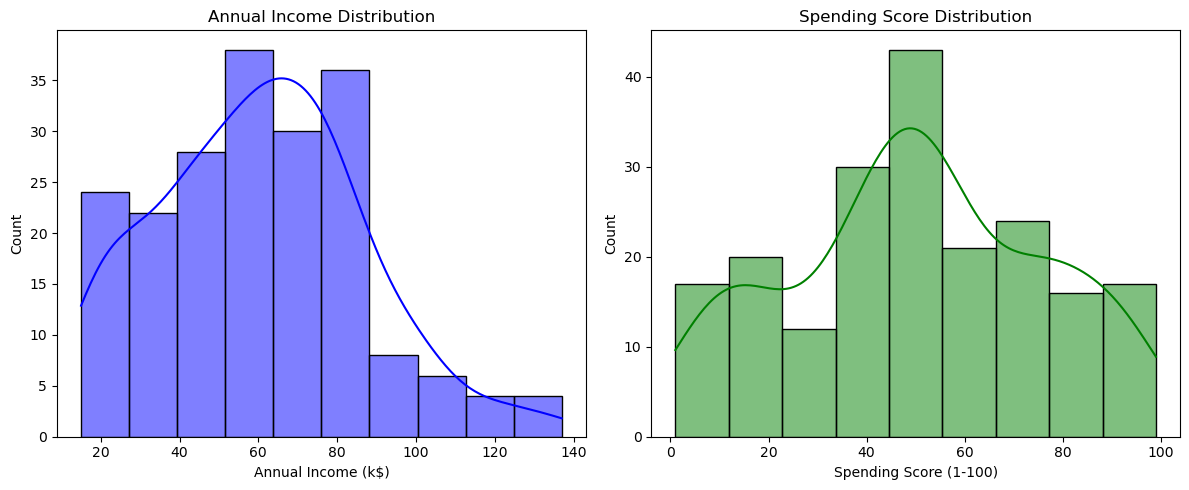

In [9]:
# Visualizing the distribution of key features
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Annual Income (k$)'], kde=True, color='blue')
plt.title('Annual Income Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['Spending Score (1-100)'], kde=True, color='green')
plt.title('Spending Score Distribution')

plt.tight_layout()
plt.show()

# Model Building & Evaluation
The optimal number of clusters is determined via the **Elbow Method**. The Within-Cluster Sum of Squares (WCSS) is calculated for various values of K, and the point of diminishing returns (the "elbow") is identified. The **K-Means algorithm** is then executed with the finalized cluster count.

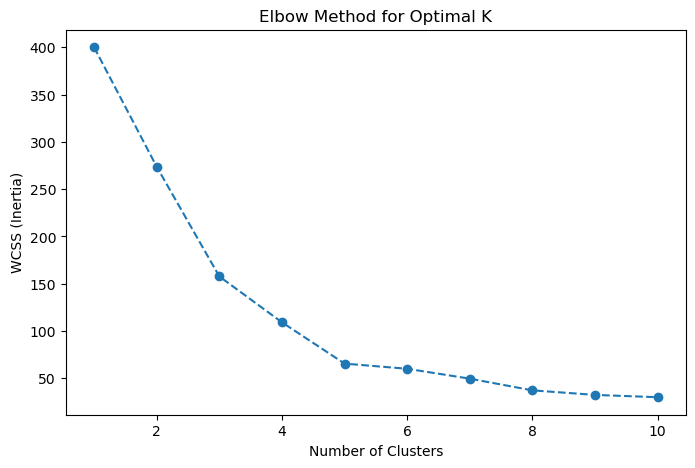

In [13]:
import warnings
warnings.filterwarnings('ignore')

# Using the Elbow Method to find the optimal number of clusters (K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

# Based on the elbow, K=5 is optimal
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# PCA Visualization
Dimensionality reduction is performed through **Principle Component Analysis (PCA).** This allows the high-dimensional clusters to be projected onto a 2D plane for visual verification.

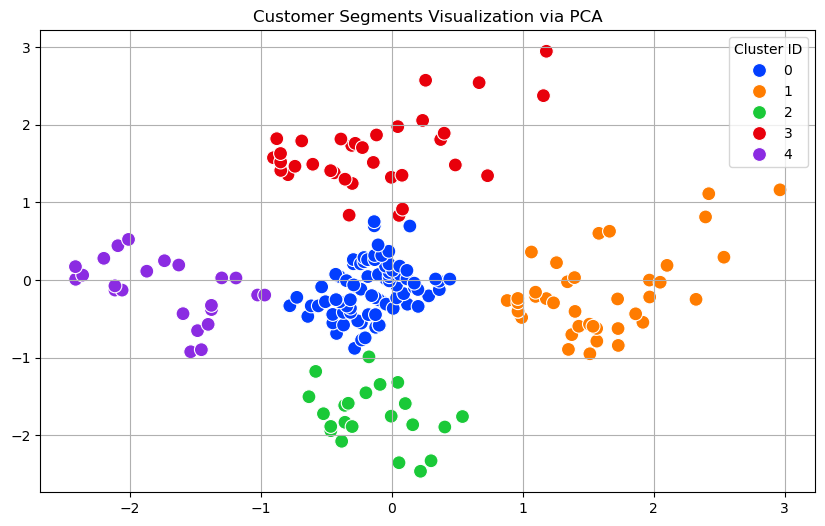

In [14]:
# Dimensionality Reduction using PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='bright', s=100)
plt.title('Customer Segments Visualization via PCA')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()

# Final Inclusion with Insights 
The final segments are analyzed and categorized. Distinct marketing strategies are proposed for each group based on their calculated average spending and income. 

In [15]:
# Summarizing the characteristics of each cluster
cluster_analysis = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Average Income and Spending per Cluster:\n", cluster_analysis)

Average Income and Spending per Cluster:
          Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043
